# Итоговый notebook: обучение и сравнение AVM-моделей

Notebook сам подтягивает данные из GitHub-репозитория:

`https://github.com/moretskayalv/parser_realty_vkr`

Используются v3-файлы:

- `train_original_before_synthetic_v3.csv`
- `synthetic_objects_geo_enriched_v3.csv`
- `test_original_not_augmented_v3.csv`

В notebook применены правки из ML-аудита:

- загрузка данных из GitHub;
- унифицирование колонок real train / synthetic train / test;
- удаление leakage-признаков `price`, `price_per_m2`, `link`;
- удаление пустых / бесполезных колонок, включая `house_number`;
- стабилизация категориальных признаков;
- sample weights: real = `1.0`, synthetic = `0.5`;
- обучение всех вариантов моделей из отчёта;
- сравнение на original test;
- сохранение лучшей production-модели `v4_CatBoost_native_MAE_depth8`.

## 1. Импорты и настройки

In [1]:
import os
import re
import sys
import json
import math
import random
import shutil
import warnings
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random_seed = 42
random_state = 42

random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

def install_if_missing(package_name, import_name=None):
    import_name = import_name or package_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

install_if_missing("catboost", "catboost")
install_if_missing("lightgbm", "lightgbm")
install_if_missing("torch", "torch")
install_if_missing("joblib", "joblib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    torch.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

REPO_URL = "https://github.com/moretskayalv/parser_realty_vkr.git"
PROJECT_DIR = Path("parser_realty_vkr")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "price"

print("Environment ready")
print("PROJECT_DIR:", PROJECT_DIR.resolve())
print("ARTIFACT_DIR:", ARTIFACT_DIR.resolve())

Installing catboost...
Environment ready
PROJECT_DIR: /content/parser_realty_vkr
ARTIFACT_DIR: /content/artifacts


## 2. Загрузка данных из GitHub

In [2]:
def run_shell(command):
    print("$", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed: {' '.join(command)}")
    return result

if not PROJECT_DIR.exists():
    run_shell(["git", "clone", REPO_URL, str(PROJECT_DIR)])
else:
    print(f"Repository already exists: {PROJECT_DIR}")
    if (PROJECT_DIR / ".git").exists():
        try:
            run_shell(["git", "-C", str(PROJECT_DIR), "pull"])
        except Exception as e:
            print("Git pull skipped:", e)

def find_file_by_name(root: Path, filename: str) -> Path:
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Не найден файл {filename} внутри {root.resolve()}.")
    if len(matches) > 1:
        print(f"Найдено несколько файлов {filename}:")
        for m in matches:
            print(" -", m)
        print("Используется первый найденный файл.")
    return matches[0]

TRAIN_REAL_PATH = find_file_by_name(PROJECT_DIR, "train_original_before_synthetic_v3.csv")
TRAIN_SYN_PATH = find_file_by_name(PROJECT_DIR, "synthetic_objects_geo_enriched_v3.csv")
TEST_PATH = find_file_by_name(PROJECT_DIR, "test_original_not_augmented_v3.csv")

print("TRAIN_REAL_PATH:", TRAIN_REAL_PATH)
print("TRAIN_SYN_PATH:", TRAIN_SYN_PATH)
print("TEST_PATH:", TEST_PATH)

train_real_raw = pd.read_csv(TRAIN_REAL_PATH)
train_syn_raw = pd.read_csv(TRAIN_SYN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print("train_real_raw shape:", train_real_raw.shape)
print("train_syn_raw shape:", train_syn_raw.shape)
print("test_raw shape:", test_raw.shape)

display(train_real_raw.head())
display(train_syn_raw.head())
display(test_raw.head())

$ git clone https://github.com/moretskayalv/parser_realty_vkr.git parser_realty_vkr
Cloning into 'parser_realty_vkr'...

TRAIN_REAL_PATH: parser_realty_vkr/train_original_before_synthetic_v3.csv
TRAIN_SYN_PATH: parser_realty_vkr/synthetic_objects_geo_enriched_v3.csv
TEST_PATH: parser_realty_vkr/test_original_not_augmented_v3.csv
train_real_raw shape: (2068, 40)
train_syn_raw shape: (4136, 40)
test_raw shape: (517, 37)


,source_group,price,area_total,rooms,floor,floors_total,address,latitude,longitude,metro,metro_walk_min,kitchen_area,renovation,walls,build_year,ceiling_height,floor_position,elevator,house_number,yard,parking,playground,link,address_source,metro_distance_km,metro_source,distance_to_center_km,distance_to_mkad_km,distance_to_school_km,distance_to_kindergarten_km,distance_to_clinic_km,distance_to_mall_km,price_per_m2,floor_ratio,house_age,has_metro_near,geo_generation_cluster,is_synthetic,generation_method,parent_geo_cluster
0,3k,44500000.0,107.0,3.0,6.0,24.0,"москва, ул. чертановская, 43к4 (14 км до центра)",55.608384,37.593318,Пражская,8.0,16.0,евроремонт,монолитные,2002.0,2.68,не угловая,"пассажирский, грузовой",43к4,двор,наземный паркинг,нет,https://msk.etagi.com/realty/11993775/,raw,0.64,geo_recomputed,16.05,3.29,0.25,0.23,0.96,0.04,415887.850467,0.250000,24.0,1,13,0,original,13
1,1k,10000000.0,34.0,1.0,7.0,9.0,"москва, ул. реутовская, 2",55.742276,37.833608,Новогиреево,12.0,9.0,косметический ремонт,панельные,2002.0,2.68,не угловая,unknown,2,детская площадка,unknown,нет,https://msk.etagi.com/realty/12502657/,raw,0.99,geo_recomputed,13.69,0.50,0.12,0.24,0.43,0.38,294117.647059,0.777778,24.0,1,24,0,original,24
2,all,12450000.0,36.6,1.0,3.0,20.0,"арм-строй, скандинавский бульвар, скандинавия,...",55.561568,37.502156,Потапово,15.0,12.0,черновая отделка,монолитные,2002.0,2.68,не угловая,unknown,2,unknown,unknown,нет,https://msk.etagi.com/realty/10956427/,geo,1.23,geo_recomputed,22.36,3.72,0.47,0.22,0.62,0.33,340163.934426,0.150000,24.0,1,8,0,original,8
3,all,10000000.0,28.1,1.0,3.0,24.0,"москва, ул. очаковское шоссе, 7 (12 км до центра)",55.692896,37.460816,Аминьевская,6.0,10.0,чистовая отделка,панельные,2002.0,2.68,не угловая,unknown,7,двор,"подземный паркинг, наземный паркинг",нет,https://msk.etagi.com/realty/12620373/,raw,0.52,geo_recomputed,11.72,2.94,0.37,0.15,0.42,0.30,355871.886121,0.125000,24.0,1,0,0,original,0
4,2k,22000000.0,60.0,2.0,7.0,25.0,"москва, ул. проезд черепановых, 10 (11 км до ц...",55.834608,37.515443,Коптево,8.0,11.0,косметический ремонт,монолитные,2002.0,2.68,не угловая,unknown,10,детская площадка,unknown,нет,https://msk.etagi.com/realty/12486760/,raw,0.63,geo_recomputed,11.10,6.16,0.64,0.54,0.55,0.46,366666.666667,0.280000,24.0,1,21,0,original,21


,source_group,price,area_total,rooms,floor,floors_total,address,latitude,longitude,metro,metro_walk_min,kitchen_area,renovation,walls,build_year,ceiling_height,floor_position,elevator,house_number,yard,parking,playground,link,address_source,metro_distance_km,metro_source,distance_to_center_km,distance_to_mkad_km,distance_to_school_km,distance_to_kindergarten_km,distance_to_clinic_km,distance_to_mall_km,price_per_m2,floor_ratio,house_age,has_metro_near,geo_generation_cluster,is_synthetic,generation_method,parent_geo_cluster
0,all,6.862750e+07,79.878919,3,29,52,"Ozon, 56, Мичуринский проспект, Кинематографич...",55.695865,37.485013,Мичуринский проспект,9,18.944037,unknown,монолитные,2002,2.73,не угловая,"пассажирский, грузовой, пассажирский и грузовой",NaN,двор,"подземный паркинг, наземный паркинг",нет,synthetic,geo,0.79,geo_recomputed,10.30,4.50,0.38,0.36,0.15,0.45,859144.088729,0.557692,24.0,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0
1,2k,2.816011e+07,55.851900,2,10,17,"93 к2, Рублёвское шоссе (дублёр), район Кунцев...",55.739905,37.425690,Молодежная,8,11.547638,unknown,панельные,2011,2.68,не угловая,"пассажирский, грузовой",NaN,двор,наземный паркинг,есть,synthetic,geo,0.65,geo_recomputed,11.96,3.20,0.33,0.14,0.32,0.24,504192.520141,0.588235,15.0,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0
2,all-mozhaiskii,4.437680e+07,93.739838,3,5,5,"Нежинская улица, Жилой комплекс «Нежинский Ков...",55.707548,37.470134,Матвеевское,10,12.027637,требует ремонта / частичный ремонт,кирпичные,2002,3.10,не угловая,"пассажирский, грузовой",NaN,двор,"наземный паркинг, подземный паркинг, гостевой ...",есть,synthetic,geo,0.82,geo_recomputed,10.37,4.04,0.27,0.14,0.76,0.08,473403.849489,1.000000,24.0,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0
3,2k,1.639678e+07,39.577583,2,6,14,"18 к2, Матвеевская улица, Матвеевское, район О...",55.703671,37.468378,Аминьевская,6,6.985481,косметический ремонт,панельные,2004,2.70,не угловая,unknown,NaN,unknown,unknown,нет,synthetic,geo,0.47,geo_recomputed,10.68,3.76,0.24,0.33,1.17,0.16,414294.749854,0.428571,22.0,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0
4,all,1.258400e+07,31.833818,1,4,5,"24 к1, улица Гришина, Можайский район, Москва,...",55.725402,37.415327,Рабочий Посёлок,2,6.419249,косметический ремонт,кирпичные,2002,2.68,не угловая,"пассажирский, грузовой",NaN,двор,наземный паркинг,есть,synthetic,geo,0.17,geo_recomputed,12.89,2.13,0.31,0.39,0.89,0.15,395302.850625,0.800000,24.0,1,0,1,geo_cluster_bootstrap_mixup_tail_v3,0


,source_group,price,area_total,rooms,floor,floors_total,address,latitude,longitude,metro,metro_walk_min,kitchen_area,renovation,walls,build_year,ceiling_height,floor_position,elevator,house_number,yard,parking,playground,link,address_source,metro_distance_km,metro_source,distance_to_center_km,distance_to_mkad_km,distance_to_school_km,distance_to_kindergarten_km,distance_to_clinic_km,distance_to_mall_km,price_per_m2,floor_ratio,house_age,has_metro_near,geo_generation_cluster
0,all,79000000.0,107.7,3.0,3.0,12.0,"москва, ул. профсоюзная, 45к1 (11 км до центра)",55.666244,37.552777,Новые Черемушки,5.0,11.5,евроремонт,панели железобетонные,2002.0,3.20,не угловая,"грузовой, пассажирский",45к1,двор,парковка во дворе,нет,https://msk.etagi.com/realty/12046394/,raw,0.44,geo_recomputed,10.34,6.56,0.32,0.14,0.34,0.34,733519.034355,0.250000,24.0,1,15
1,all-khamovniki,28000000.0,45.4,2.0,2.0,12.0,"москва, ул. усачёва, 25",55.724941,37.565138,Спортивная,4.0,9.0,косметический ремонт,кирпич красный,2002.0,2.68,не угловая,unknown,25,детская площадка,unknown,нет,https://msk.etagi.com/realty/12595916/,raw,0.34,geo_recomputed,4.38,10.28,0.12,0.08,0.13,0.26,616740.088106,0.166667,24.0,1,10
2,all,19499000.0,27.0,0.0,3.0,39.0,"москва, ул. лётная",55.820420,37.420877,Спартак,11.0,7.0,черновая отделка,монолитно-кирпичный,2002.0,2.68,не угловая,unknown,2,unknown,unknown,нет,https://msk.etagi.com/realty/12035321/,raw,0.93,geo_recomputed,14.34,1.77,0.63,0.56,0.69,0.65,722185.185185,0.076923,24.0,1,2
3,all,114000000.0,125.9,4.0,25.0,32.0,"москва, ул. летниковская, 11к1 (4 км до центра)",55.726183,37.644962,Павелецкая,7.0,15.0,без отделки,монолитные,2002.0,2.68,не угловая,unknown,11к1,детская площадка,unknown,нет,https://msk.etagi.com/realty/12227773/,raw,0.56,geo_recomputed,3.43,12.02,0.63,0.35,0.34,0.22,905480.540111,0.781250,24.0,1,20
4,all,47900000.0,67.0,3.0,6.0,15.0,"москва, ул. новая дорога, 9 (6 км до центра)",55.772350,37.700783,Лефортово,11.0,13.5,косметический ремонт,сборно-монолитный железобетонный каркас,2022.0,3.00,не угловая,"пассажирский, грузовой",9,двор,подземный паркинг,нет,https://msk.etagi.com/realty/10832761/,raw,0.89,geo_recomputed,5.78,8.90,0.36,0.19,0.27,0.70,714925.373134,0.400000,4.0,1,7


## 3. Унифицирование колонок real train / synthetic / test

In [3]:
def normalize_column_name(col):
    col = str(col).strip()
    col = col.replace("\n", " ").replace("\t", " ")
    col = "_".join(col.split())
    while "__" in col:
        col = col.replace("__", "_")
    return col

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [normalize_column_name(c) for c in df.columns]
    df = df.loc[:, ~pd.Index(df.columns).duplicated()]
    return df

train_real = normalize_columns(train_real_raw)
train_syn = normalize_columns(train_syn_raw)
test_df = normalize_columns(test_raw)

for name, df in [("real train", train_real), ("synthetic train", train_syn), ("test", test_df)]:
    if TARGET_COL not in df.columns:
        raise ValueError(f"В {name} нет target-колонки `{TARGET_COL}`.")

train_real["is_synthetic"] = 0
train_syn["is_synthetic"] = 1
test_df["is_synthetic"] = 0

real_cols = set(train_real.columns)
syn_cols = set(train_syn.columns)
test_cols = set(test_df.columns)

common_all_cols = sorted(list(real_cols & syn_cols & test_cols))
required_cols = {TARGET_COL, "is_synthetic"}
common_all_cols = sorted(list((set(common_all_cols) | required_cols) & real_cols & syn_cols & test_cols))

column_unification_report = {
    "n_cols_real": len(real_cols),
    "n_cols_synthetic": len(syn_cols),
    "n_cols_test": len(test_cols),
    "n_common_all": len(common_all_cols),
    "real_not_in_all": sorted(list(real_cols - set(common_all_cols))),
    "synthetic_not_in_all": sorted(list(syn_cols - set(common_all_cols))),
    "test_not_in_all": sorted(list(test_cols - set(common_all_cols))),
}

with open(ARTIFACT_DIR / "column_unification_report.json", "w", encoding="utf-8") as f:
    json.dump(column_unification_report, f, ensure_ascii=False, indent=2)

ordered_cols = [TARGET_COL] + [c for c in common_all_cols if c not in {TARGET_COL, "is_synthetic"}] + ["is_synthetic"]

train_real_u = train_real[ordered_cols].copy()
train_syn_u = train_syn[ordered_cols].copy()
test_u = test_df[ordered_cols].copy()

print("Column unification summary:")
print("real columns:", len(real_cols))
print("synthetic columns:", len(syn_cols))
print("test columns:", len(test_cols))
print("common columns used:", len(common_all_cols))
print("Report saved to:", ARTIFACT_DIR / "column_unification_report.json")

display(pd.DataFrame({
    "dataset": ["real_train", "synthetic_train", "test"],
    "rows": [len(train_real_u), len(train_syn_u), len(test_u)],
    "cols_after_unification": [train_real_u.shape[1], train_syn_u.shape[1], test_u.shape[1]],
}))

Column unification summary:
real columns: 40
synthetic columns: 40
test columns: 38
common columns used: 38
Report saved to: artifacts/column_unification_report.json


,dataset,rows,cols_after_unification
0,real_train,2068,38
1,synthetic_train,4136,38
2,test,517,38


## 4. Очистка и препроцессинг: применение правок из аудита

In [4]:
train_df = pd.concat([train_real_u, train_syn_u], ignore_index=True)
test_df = test_u.copy()

y_train_raw = train_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

sample_weight = np.where(train_df["is_synthetic"].values == 1, 0.5, 1.0)

LEAKAGE_COLS = ["price", "price_per_m2", "link"]
USELESS_COLS = ["house_number"]
TECHNICAL_COLS = []

drop_cols = set(LEAKAGE_COLS + USELESS_COLS + TECHNICAL_COLS)

feature_cols = [
    col for col in train_df.columns
    if col in test_df.columns and col not in drop_cols
]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Удаляем полностью пустые признаки.
all_empty_cols = [
    col for col in X_train.columns
    if X_train[col].isna().all() and X_test[col].isna().all()
]
if all_empty_cols:
    print("Удаляются полностью пустые колонки:", all_empty_cols)
    X_train = X_train.drop(columns=all_empty_cols)
    X_test = X_test.drop(columns=all_empty_cols)

# Удаляем константные признаки на train.
constant_cols = [
    col for col in X_train.columns
    if X_train[col].nunique(dropna=False) <= 1
]
if constant_cols:
    print("Удаляются константные колонки:", constant_cols)
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)

print("Combined train shape:", train_df.shape)
print("Final X_train shape before categorical stabilization:", X_train.shape)
print("Final X_test shape before categorical stabilization:", X_test.shape)
print("Sample weights:")
print(pd.Series(sample_weight).value_counts().sort_index())

display(X_train.head())

Удаляются константные колонки: ['metro_source']
Combined train shape: (6204, 38)
Final X_train shape before categorical stabilization: (6204, 33)
Final X_test shape before categorical stabilization: (517, 33)
Sample weights:
0.5    4136
1.0    2068
Name: count, dtype: int64


,address,address_source,area_total,build_year,ceiling_height,distance_to_center_km,distance_to_clinic_km,distance_to_kindergarten_km,distance_to_mall_km,distance_to_mkad_km,distance_to_school_km,elevator,floor,floor_position,floor_ratio,floors_total,geo_generation_cluster,has_metro_near,house_age,kitchen_area,latitude,longitude,metro,metro_distance_km,metro_walk_min,parking,playground,renovation,rooms,source_group,walls,yard,is_synthetic
0,"москва, ул. чертановская, 43к4 (14 км до центра)",raw,107.0,2002.0,2.68,16.05,0.96,0.23,0.04,3.29,0.25,"пассажирский, грузовой",6.0,не угловая,0.250000,24.0,13,1,24.0,16.0,55.608384,37.593318,Пражская,0.64,8.0,наземный паркинг,нет,евроремонт,3.0,3k,монолитные,двор,0
1,"москва, ул. реутовская, 2",raw,34.0,2002.0,2.68,13.69,0.43,0.24,0.38,0.50,0.12,unknown,7.0,не угловая,0.777778,9.0,24,1,24.0,9.0,55.742276,37.833608,Новогиреево,0.99,12.0,unknown,нет,косметический ремонт,1.0,1k,панельные,детская площадка,0
2,"арм-строй, скандинавский бульвар, скандинавия,...",geo,36.6,2002.0,2.68,22.36,0.62,0.22,0.33,3.72,0.47,unknown,3.0,не угловая,0.150000,20.0,8,1,24.0,12.0,55.561568,37.502156,Потапово,1.23,15.0,unknown,нет,черновая отделка,1.0,all,монолитные,unknown,0
3,"москва, ул. очаковское шоссе, 7 (12 км до центра)",raw,28.1,2002.0,2.68,11.72,0.42,0.15,0.30,2.94,0.37,unknown,3.0,не угловая,0.125000,24.0,0,1,24.0,10.0,55.692896,37.460816,Аминьевская,0.52,6.0,"подземный паркинг, наземный паркинг",нет,чистовая отделка,1.0,all,панельные,двор,0
4,"москва, ул. проезд черепановых, 10 (11 км до ц...",raw,60.0,2002.0,2.68,11.10,0.55,0.54,0.46,6.16,0.64,unknown,7.0,не угловая,0.280000,25.0,21,1,24.0,11.0,55.834608,37.515443,Коптево,0.63,8.0,unknown,нет,косметический ремонт,2.0,2k,монолитные,детская площадка,0


## 5. Удаление колонок-маркеров синтетики

Этот этап удаляет признаки, которые явно или косвенно сообщают модели, был ли объект синтетически сгенерирован.

Почему это важно:

- если оставить `is_synthetic`, `generation_method`, `parent_geo_cluster`, `parent_id`, `source_row`, `address_source`, `source_group` и похожие признаки, модель может читерски использовать факт синтетики;
- это является формой data leakage;
- test состоит из оригинальных объектов, поэтому маркеры синтетики не должны участвовать в обучении.

Важно: `geo_generation_cluster` **не удаляется**, потому что это пространственный гео-признак, а не маркер синтетики.

In [5]:
# Выводим список всех колонок в объединённом train.
print("Все колонки в объединённом train_df:")
for i, col in enumerate(train_df.columns, start=1):
    print(f"{i:03d}. {col}")

cols_before_train = X_train.shape[1]
cols_before_test = X_test.shape[1]

print("\nРазмер feature matrix до удаления маркеров синтетики:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# Явные служебные маркеры синтетики из пайплайна / README.
explicit_synthetic_marker_cols = {
    "is_synthetic",
    "generation_method",
    "parent_geo_cluster",
    "address_source",
    "source_group",
}

# Идентификаторы / ссылки на исходные объекты, которые могут раскрывать происхождение synthetic rows.
source_id_marker_patterns = [
    "parent_id",
    "source_row",
    "original_index",
    "address_source",
    "source_group",
]

# Паттерны в названии, которые указывают на синтетическое происхождение.
# Важно: намеренно НЕ используем общий паттерн "generation",
# чтобы не удалить полезный пространственный признак geo_generation_cluster.
name_marker_patterns = [
    "synthetic",
    "is_synth",
    "generation_method",
    "parent_",
    "augmented",
]

# Колонки, которые нельзя удалять этим блоком.
# geo_generation_cluster является полезным пространственным признаком.
protected_cols = {
    "geo_generation_cluster",
}

def is_binary_like_marker(series: pd.Series) -> bool:
    """
    Проверяет, является ли колонка бинарной 0/1 или True/False.
    Само по себе это ещё не причина удалить колонку, поэтому ниже дополнительно
    проверяется совпадение с is_synthetic.
    """
    non_null = series.dropna()

    if non_null.empty:
        return False

    normalized_values = set(
        str(v).strip().lower()
        for v in non_null.unique()
    )

    allowed_binary_sets = [
        {"0", "1"},
        {"true", "false"},
        {"0.0", "1.0"},
        {"0", "1", "0.0", "1.0"},
        {"true", "false", "0", "1"},
    ]

    return any(normalized_values.issubset(s) for s in allowed_binary_sets)

def binary_matches_synthetic_marker(candidate: pd.Series, synthetic_marker: pd.Series) -> bool:
    """
    Проверяет, совпадает ли бинарная колонка с разделением real/synthetic.
    Используется только для диагностики потенциальных скрытых маркеров.
    """
    try:
        cand = candidate.copy()
        synth = synthetic_marker.copy()

        cand_norm = cand.astype(str).str.strip().str.lower()
        synth_norm = synth.astype(str).str.strip().str.lower()

        mapping = {
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0,
            "1.0": 1,
            "0.0": 0,
        }

        cand_num = cand_norm.map(mapping)
        synth_num = synth_norm.map(mapping)

        valid_mask = cand_num.notna() & synth_num.notna()

        if valid_mask.sum() == 0:
            return False

        match_rate = (cand_num[valid_mask].astype(int) == synth_num[valid_mask].astype(int)).mean()

        return bool(match_rate >= 0.98)

    except Exception:
        return False

synthetic_marker_reasons = {}

# Ищем маркеры по всем колонкам объединённого train_df.
for col in train_df.columns:
    col_lower = col.lower()

    if col in protected_cols:
        continue

    reasons = []

    # 1. Явные служебные колонки.
    if col in explicit_synthetic_marker_cols:
        reasons.append("явный служебный маркер синтетики")

    # 2. Поиск по паттернам в названии.
    if any(pattern in col_lower for pattern in name_marker_patterns):
        reasons.append("название содержит synthetic/is_synth/generation_method/parent_/augmented")

    # 3. Идентификаторы исходных объектов.
    if any(pattern in col_lower for pattern in source_id_marker_patterns):
        reasons.append("служебный source-маркер или идентификатор исходного объекта")

    # 4. Бинарные колонки, совпадающие с разделением real/synthetic.
    if (
        col in train_df.columns
        and "is_synthetic" in train_df.columns
        and col != "is_synthetic"
        and is_binary_like_marker(train_df[col])
        and binary_matches_synthetic_marker(train_df[col], train_df["is_synthetic"])
    ):
        reasons.append("бинарная колонка 0/1 или True/False, совпадает с разделением real/synthetic")

    if reasons:
        synthetic_marker_reasons[col] = "; ".join(sorted(set(reasons)))

# Удаляем только те найденные маркеры, которые реально присутствуют в feature matrix.
# price / leakage уже удаляются отдельным этапом, target здесь не трогаем.
synthetic_marker_cols_to_drop_train = [
    col for col in synthetic_marker_reasons
    if col in X_train.columns and col not in protected_cols
]

synthetic_marker_cols_to_drop_test = [
    col for col in synthetic_marker_reasons
    if col in X_test.columns and col not in protected_cols
]

print("\nНайденные колонки-маркеры синтетики и причины удаления:")
if synthetic_marker_reasons:
    marker_report_df = pd.DataFrame(
        [
            {
                "column": col,
                "reason": reason,
                "in_X_train": col in X_train.columns,
                "in_X_test": col in X_test.columns,
                "train_value_counts": train_df[col].value_counts(dropna=False).head(10).to_dict()
                    if col in train_df.columns else {},
            }
            for col, reason in synthetic_marker_reasons.items()
        ]
    ).sort_values("column")

    display(marker_report_df)

    marker_report_df.to_csv(
        ARTIFACT_DIR / "synthetic_marker_columns_report.csv",
        index=False,
        encoding="utf-8-sig"
    )
else:
    print("Маркеры синтетики не найдены.")

# Удаляем маркеры из train feature matrix.
if synthetic_marker_cols_to_drop_train:
    X_train = X_train.drop(columns=synthetic_marker_cols_to_drop_train)

# Проверяем test и удаляем аналогичные колонки, если они там есть.
if synthetic_marker_cols_to_drop_test:
    X_test = X_test.drop(columns=synthetic_marker_cols_to_drop_test)

print("\nПроверка protected-признака:")
if "geo_generation_cluster" in X_train.columns:
    print("geo_generation_cluster сохранён в X_train.")
else:
    print("geo_generation_cluster отсутствует в X_train исходно или был удалён ранее не этим блоком.")

print("\nРазмер feature matrix после удаления маркеров синтетики:")
print("X_train:", X_train.shape, f"(было колонок: {cols_before_train}, стало: {X_train.shape[1]})")
print("X_test:", X_test.shape, f"(было колонок: {cols_before_test}, стало: {X_test.shape[1]})")

print("\nУдалено из X_train:", synthetic_marker_cols_to_drop_train)
print("Удалено из X_test:", synthetic_marker_cols_to_drop_test)

print("\nПервые 3 строки X_train после удаления маркеров:")
display(X_train.head(3))

print("\nПервые 3 строки X_test после удаления маркеров:")
display(X_test.head(3))

Все колонки в объединённом train_df:
001. price
002. address
003. address_source
004. area_total
005. build_year
006. ceiling_height
007. distance_to_center_km
008. distance_to_clinic_km
009. distance_to_kindergarten_km
010. distance_to_mall_km
011. distance_to_mkad_km
012. distance_to_school_km
013. elevator
014. floor
015. floor_position
016. floor_ratio
017. floors_total
018. geo_generation_cluster
019. has_metro_near
020. house_age
021. house_number
022. kitchen_area
023. latitude
024. link
025. longitude
026. metro
027. metro_distance_km
028. metro_source
029. metro_walk_min
030. parking
031. playground
032. price_per_m2
033. renovation
034. rooms
035. source_group
036. walls
037. yard
038. is_synthetic

Размер feature matrix до удаления маркеров синтетики:
X_train: (6204, 33)
X_test: (517, 33)

Найденные колонки-маркеры синтетики и причины удаления:


,column,reason,in_X_train,in_X_test,train_value_counts
0,address_source,служебный source-маркер или идентификатор исхо...,True,True,"{'geo': 4455, 'raw': 1749}"
2,is_synthetic,название содержит synthetic/is_synth/generatio...,True,True,"{1: 4136, 0: 2068}"
1,source_group,служебный source-маркер или идентификатор исхо...,True,True,"{'all': 2989, '2k': 622, '1k': 531, '3k': 406,..."



Проверка protected-признака:
geo_generation_cluster сохранён в X_train.

Размер feature matrix после удаления маркеров синтетики:
X_train: (6204, 30) (было колонок: 33, стало: 30)
X_test: (517, 30) (было колонок: 33, стало: 30)

Удалено из X_train: ['address_source', 'source_group', 'is_synthetic']
Удалено из X_test: ['address_source', 'source_group', 'is_synthetic']

Первые 3 строки X_train после удаления маркеров:


,address,area_total,build_year,ceiling_height,distance_to_center_km,distance_to_clinic_km,distance_to_kindergarten_km,distance_to_mall_km,distance_to_mkad_km,distance_to_school_km,elevator,floor,floor_position,floor_ratio,floors_total,geo_generation_cluster,has_metro_near,house_age,kitchen_area,latitude,longitude,metro,metro_distance_km,metro_walk_min,parking,playground,renovation,rooms,walls,yard
0,"москва, ул. чертановская, 43к4 (14 км до центра)",107.0,2002.0,2.68,16.05,0.96,0.23,0.04,3.29,0.25,"пассажирский, грузовой",6.0,не угловая,0.250000,24.0,13,1,24.0,16.0,55.608384,37.593318,Пражская,0.64,8.0,наземный паркинг,нет,евроремонт,3.0,монолитные,двор
1,"москва, ул. реутовская, 2",34.0,2002.0,2.68,13.69,0.43,0.24,0.38,0.50,0.12,unknown,7.0,не угловая,0.777778,9.0,24,1,24.0,9.0,55.742276,37.833608,Новогиреево,0.99,12.0,unknown,нет,косметический ремонт,1.0,панельные,детская площадка
2,"арм-строй, скандинавский бульвар, скандинавия,...",36.6,2002.0,2.68,22.36,0.62,0.22,0.33,3.72,0.47,unknown,3.0,не угловая,0.150000,20.0,8,1,24.0,12.0,55.561568,37.502156,Потапово,1.23,15.0,unknown,нет,черновая отделка,1.0,монолитные,unknown



Первые 3 строки X_test после удаления маркеров:


,address,area_total,build_year,ceiling_height,distance_to_center_km,distance_to_clinic_km,distance_to_kindergarten_km,distance_to_mall_km,distance_to_mkad_km,distance_to_school_km,elevator,floor,floor_position,floor_ratio,floors_total,geo_generation_cluster,has_metro_near,house_age,kitchen_area,latitude,longitude,metro,metro_distance_km,metro_walk_min,parking,playground,renovation,rooms,walls,yard
0,"москва, ул. профсоюзная, 45к1 (11 км до центра)",107.7,2002.0,3.20,10.34,0.34,0.14,0.34,6.56,0.32,"грузовой, пассажирский",3.0,не угловая,0.250000,12.0,15,1,24.0,11.5,55.666244,37.552777,Новые Черемушки,0.44,5.0,парковка во дворе,нет,евроремонт,3.0,панели железобетонные,двор
1,"москва, ул. усачёва, 25",45.4,2002.0,2.68,4.38,0.13,0.08,0.26,10.28,0.12,unknown,2.0,не угловая,0.166667,12.0,10,1,24.0,9.0,55.724941,37.565138,Спортивная,0.34,4.0,unknown,нет,косметический ремонт,2.0,кирпич красный,детская площадка
2,"москва, ул. лётная",27.0,2002.0,2.68,14.34,0.69,0.56,0.65,1.77,0.63,unknown,3.0,не угловая,0.076923,39.0,2,1,24.0,7.0,55.820420,37.420877,Спартак,0.93,11.0,unknown,нет,черновая отделка,0.0,монолитно-кирпичный,unknown


## 6. Стабилизация категориальных признаков

Критически важный этап перед обучением.

Стабилизация применяется одинаково к train и test:

- приведение к нижнему регистру;
- удаление пробелов в начале и конце;
- замена множественных пробелов на один;
- замена пустых строк, `nan`, `none`, `null` на `unknown`;
- унификация синонимов для `renovation`, `parking`, `walls`;
- стабилизация `metro`: удаление `м.`, удаление всего после запятой, нормализация пробелов;
- вывод количества уникальных значений до / после и примеров значений;
- после стабилизации заново фиксируются `cat_cols` и `cat_feature_indices` для CatBoost.

In [6]:
# Определяем категориальные колонки автоматически после удаления leakage-признаков.
cat_cols_before = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Сохраняем диагностику до стабилизации.
cat_diagnostics_before = {}
for col in cat_cols_before:
    cat_diagnostics_before[col] = {
        "train_nunique_before": int(X_train[col].nunique(dropna=False)),
        "test_nunique_before": int(X_test[col].nunique(dropna=False)),
        "train_examples_before": X_train[col].dropna().astype(str).head(5).tolist(),
        "test_examples_before": X_test[col].dropna().astype(str).head(5).tolist(),
    }

# Словари унификации синонимов.
RENOVATION_MAP = {
    "без ремонта": "без отделки",
    "без отделки": "без отделки",
    "нет ремонта": "без отделки",
    "требует ремонта": "без отделки",
    "косметический": "косметический",
    "косметич": "косметический",
    "косметика": "косметический",
    "евроремонт": "евроремонт",
    "евро": "евроремонт",
    "евро ремонт": "евроремонт",
    "дизайнерский": "дизайнерский",
    "дизайнерский ремонт": "дизайнерский",
}

PARKING_MAP = {
    "отсутствует": "нет",
    "нет": "нет",
    "none": "нет",
    "no": "нет",
    "без парковки": "нет",
    "гостевая": "гостевая",
    "гостевой": "гостевая",
    "подземная": "подземная",
    "подземный": "подземная",
    "наземная": "наземная",
    "наземный": "наземная",
    "многоуровневая": "многоуровневая",
    "многоуровневый": "многоуровневая",
}

WALLS_MAP = {
    "кирпич": "кирпич",
    "кирпичный": "кирпич",
    "кирпичные": "кирпич",
    "монолит": "монолит",
    "монолитный": "монолит",
    "монолитные": "монолит",
    "панель": "панель",
    "панельный": "панель",
    "панельные": "панель",
    "блочный": "блочный",
    "блоки": "блочный",
    "блок": "блочный",
}

def normalize_text_value(value):
    """Базовая стабилизация текстового значения."""
    if pd.isna(value):
        return "unknown"

    value = str(value).lower().strip()
    value = re.sub(r"\s+", " ", value)

    if value in {"", "nan", "none", "null", "na", "n/a", "-", "—"}:
        return "unknown"

    return value

def stabilize_metro_value(value):
    """Стабилизация названия станции метро."""
    value = normalize_text_value(value)

    if value == "unknown":
        return value

    # Удаляем префиксы вида "м.", "м ", "метро ".
    value = re.sub(r"^м\.\s*", "", value)
    value = re.sub(r"^м\s+", "", value)
    value = re.sub(r"^метро\s+", "", value)

    # Если в строке есть доп. информация после запятой, оставляем только станцию.
    value = value.split(",")[0].strip()

    # Повторная нормализация пробелов.
    value = re.sub(r"\s+", " ", value).strip()

    if value in {"", "nan", "none", "null", "-", "—"}:
        return "unknown"

    return value

def apply_synonym_mapping(col_name, value):
    """Унификация синонимов по имени колонки."""
    col_lower = col_name.lower()

    if "renovation" in col_lower or "repair" in col_lower or "ремонт" in col_lower:
        return RENOVATION_MAP.get(value, value)

    if "parking" in col_lower or "парков" in col_lower:
        return PARKING_MAP.get(value, value)

    if "walls" in col_lower or "wall" in col_lower or "стен" in col_lower or "material" in col_lower:
        return WALLS_MAP.get(value, value)

    return value

def stabilize_categorical_column(series: pd.Series, col_name: str) -> pd.Series:
    """Единая функция стабилизации категориальной колонки."""
    if "metro" in col_name.lower() or "метро" in col_name.lower():
        stable = series.apply(stabilize_metro_value)
    else:
        stable = series.apply(normalize_text_value)

    stable = stable.apply(lambda x: apply_synonym_mapping(col_name, x))
    stable = stable.replace({"": "unknown", "nan": "unknown", "none": "unknown", "null": "unknown"})
    stable = stable.fillna("unknown").astype(str)

    return stable

def stabilize_categorical_features(X_train_in: pd.DataFrame, X_test_in: pd.DataFrame, cat_cols):
    """Применяет одинаковую стабилизацию к train и test."""
    X_train_out = X_train_in.copy()
    X_test_out = X_test_in.copy()

    for col in cat_cols:
        X_train_out[col] = stabilize_categorical_column(X_train_out[col], col)
        X_test_out[col] = stabilize_categorical_column(X_test_out[col], col)

    return X_train_out, X_test_out

X_train, X_test = stabilize_categorical_features(X_train, X_test, cat_cols_before)

# Диагностика после стабилизации.
cat_diagnostics_after = []
for col in cat_cols_before:
    row = {
        "column": col,
        "train_nunique_before": cat_diagnostics_before[col]["train_nunique_before"],
        "train_nunique_after": int(X_train[col].nunique(dropna=False)),
        "test_nunique_before": cat_diagnostics_before[col]["test_nunique_before"],
        "test_nunique_after": int(X_test[col].nunique(dropna=False)),
        "train_examples_before": cat_diagnostics_before[col]["train_examples_before"],
        "train_examples_after": X_train[col].dropna().astype(str).head(5).tolist(),
        "test_examples_before": cat_diagnostics_before[col]["test_examples_before"],
        "test_examples_after": X_test[col].dropna().astype(str).head(5).tolist(),
    }
    cat_diagnostics_after.append(row)

cat_stabilization_report = pd.DataFrame(cat_diagnostics_after)
display(cat_stabilization_report)

cat_stabilization_report.to_csv(
    ARTIFACT_DIR / "categorical_stabilization_report.csv",
    index=False,
    encoding="utf-8-sig"
)

# Вывод value_counts для каждой обработанной категориальной колонки.
for col in cat_cols_before:
    print("\n" + "=" * 90)
    print(f"VALUE_COUNTS после стабилизации: {col}")
    print("=" * 90)
    print(X_train[col].value_counts(dropna=False).head(30))

# После стабилизации заново определяем категориальные и числовые колонки.
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Для CatBoost native категории должны быть строками.
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna("unknown").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("unknown").astype(str)

cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in cat_cols]

print("\nИтог после стабилизации:")
print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("Categorical columns list:", cat_cols)
print("CatBoost cat_feature_indices:", cat_feature_indices)

,column,train_nunique_before,train_nunique_after,test_nunique_before,test_nunique_after,train_examples_before,train_examples_after,test_examples_before,test_examples_after
0,address,5016,4918,493,493,"[москва, ул. чертановская, 43к4 (14 км до цент...","[москва, ул. чертановская, 43к4 (14 км до цент...","[москва, ул. профсоюзная, 45к1 (11 км до центр...","[москва, ул. профсоюзная, 45к1 (11 км до центр..."
1,elevator,12,12,11,11,"[пассажирский, грузовой, unknown, unknown, unk...","[пассажирский, грузовой, unknown, unknown, unk...","[грузовой, пассажирский, unknown, unknown, unk...","[грузовой, пассажирский, unknown, unknown, unk..."
2,floor_position,2,2,2,2,"[не угловая, не угловая, не угловая, не углова...","[не угловая, не угловая, не угловая, не углова...","[не угловая, не угловая, не угловая, не углова...","[не угловая, не угловая, не угловая, не углова..."
3,metro,296,296,207,207,"[Пражская, Новогиреево, Потапово, Аминьевская,...","[пражская, новогиреево, потапово, аминьевская,...","[Новые Черемушки, Спортивная, Спартак, Павелец...","[новые черемушки, спортивная, спартак, павелец..."
4,parking,43,43,22,22,"[наземный паркинг, unknown, unknown, подземный...","[наземный паркинг, unknown, unknown, подземный...","[парковка во дворе, unknown, unknown, unknown,...","[парковка во дворе, unknown, unknown, unknown,..."
5,playground,2,2,2,2,"[нет, нет, нет, нет, нет]","[нет, нет, нет, нет, нет]","[нет, нет, нет, нет, нет]","[нет, нет, нет, нет, нет]"
6,renovation,17,17,15,15,"[евроремонт, косметический ремонт, черновая от...","[евроремонт, косметический ремонт, черновая от...","[евроремонт, косметический ремонт, черновая от...","[евроремонт, косметический ремонт, черновая от..."
7,walls,46,46,28,28,"[монолитные, панельные, монолитные, панельные,...","[монолит, панель, монолит, панель, монолит]","[панели железобетонные, кирпич красный, моноли...","[панели железобетонные, кирпич красный, моноли..."
8,yard,4,4,4,4,"[двор, детская площадка, unknown, двор, детска...","[двор, детская площадка, unknown, двор, детска...","[двор, детская площадка, unknown, детская площ...","[двор, детская площадка, unknown, детская площ..."



VALUE_COUNTS после стабилизации: address
address
20, новоостаповская улица, кожухово, южнопортовый район, москва, центральный федеральный округ, 115088, россия                              21
автомобильный проезд, нижегородский район, москва, центральный федеральный округ, 109029, россия                                            16
1, проезд стройкомбината, очаково, район очаково-матвеевское, москва, центральный федеральный округ, 119530, россия                         13
очаковское шоссе, район очаково-матвеевское, москва, центральный федеральный округ, 119530, россия                                          12
улица борисовские пруды, район москворечье-сабурово, москва, центральный федеральный округ, 115211, россия                                  11
7, очаковское шоссе, район очаково-матвеевское, москва, центральный федеральный округ, 119530, россия                                       11
5а к2, новогиреевская улица, район перово, москва, центральный федеральный округ, 111399, ро

## Удаление категориальных признаков с большим числом вариаций

После стабилизации категориальных значений дополнительно удаляются категориальные признаки, в которых слишком много уникальных вариантов.

Правило:

- если категориальная колонка имеет больше `3` уникальных значений на train, она удаляется;
- те же колонки удаляются из test, если присутствуют;
- после удаления заново пересчитываются `cat_cols`, `num_cols`, `X_train_cb`, `X_test_cb`, `cat_feature_indices`.

Это снижает риск переобучения на высококардинальных текстовых признаках. При этом `metro` и `address` защищены от удаления, потому что они несут ключевой локационный сигнал для рынка недвижимости Москвы.

Исключения:

- `metro` не удаляется;
- `address` не удаляется;
- колонки, содержащие `метро` или `адрес`, также не удаляются.


In [7]:
# Порог максимального числа уникальных значений для категориального признака.
# По требованию: удаляем признаки, где больше 3 вариаций.
HIGH_CARDINALITY_CAT_THRESHOLD = 3

# Защитный список: признаки, которые нельзя удалять даже при высокой кардинальности.
# Для недвижимости Москвы metro и address несут ключевой локационный сигнал.
PROTECTED_HIGH_CARDINALITY_COLS = {
    "metro",
    "address",
}

cat_cols_current = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

high_cardinality_report_rows = []
high_cardinality_cols_to_drop = []

for col in cat_cols_current:
    train_nunique = int(X_train[col].nunique(dropna=False))
    test_nunique = int(X_test[col].nunique(dropna=False)) if col in X_test.columns else None

    row = {
        "column": col,
        "train_nunique": train_nunique,
        "test_nunique": test_nunique,
        "threshold": HIGH_CARDINALITY_CAT_THRESHOLD,
        "drop": False,
        "reason": "",
        "top_train_values": X_train[col].value_counts(dropna=False).head(10).to_dict(),
    }

    col_lower = col.lower()

    is_location_protected = (
        col in PROTECTED_HIGH_CARDINALITY_COLS
        or "metro" in col_lower
        or "метро" in col_lower
        or "address" in col_lower
        or "адрес" in col_lower
    )

    if is_location_protected:
        row["drop"] = False
        row["reason"] = "protected location column: metro/address"
    elif train_nunique > HIGH_CARDINALITY_CAT_THRESHOLD:
        row["drop"] = True
        row["reason"] = f"categorical cardinality > {HIGH_CARDINALITY_CAT_THRESHOLD}"
        high_cardinality_cols_to_drop.append(col)

    high_cardinality_report_rows.append(row)

high_cardinality_report = pd.DataFrame(high_cardinality_report_rows)

print("Отчёт по кардинальности категориальных признаков:")
display(high_cardinality_report.sort_values(["drop", "train_nunique"], ascending=[False, False]))

high_cardinality_report_path = ARTIFACT_DIR / "high_cardinality_categorical_features_report.csv"
high_cardinality_report.to_csv(high_cardinality_report_path, index=False, encoding="utf-8-sig")

print("Отчёт сохранён:", high_cardinality_report_path)

print("\nРазмеры до удаления high-cardinality categorical features:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nКатегориальные признаки к удалению:")
print(high_cardinality_cols_to_drop)

if high_cardinality_cols_to_drop:
    X_train = X_train.drop(columns=high_cardinality_cols_to_drop, errors="ignore")
    X_test = X_test.drop(columns=high_cardinality_cols_to_drop, errors="ignore")

print("\nРазмеры после удаления high-cardinality categorical features:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nПервые 3 строки X_train после удаления high-cardinality категориальных признаков:")
display(X_train.head(3))

print("\nПервые 3 строки X_test после удаления high-cardinality категориальных признаков:")
display(X_test.head(3))

# После удаления high-cardinality категориальных признаков обязательно заново определяем признаки.
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Для CatBoost native категории должны быть строками.
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna("unknown").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("unknown").astype(str)

cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in cat_cols]

print("\nИтог после удаления high-cardinality категориальных признаков:")
print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("Categorical columns list:", cat_cols)
print("CatBoost cat_feature_indices:", cat_feature_indices)

Отчёт по кардинальности категориальных признаков:


,column,train_nunique,test_nunique,threshold,drop,reason,top_train_values
7,walls,46,28,3,True,categorical cardinality > 3,"{'монолит': 1840, 'панель': 1291, 'кирпич': 85..."
4,parking,43,22,3,True,categorical cardinality > 3,"{'unknown': 2192, 'наземный паркинг': 1603, 'н..."
6,renovation,17,15,3,True,categorical cardinality > 3,"{'косметический ремонт': 1873, 'евроремонт': 1..."
1,elevator,12,11,3,True,categorical cardinality > 3,"{'unknown': 3450, 'пассажирский, грузовой': 16..."
8,yard,4,4,3,True,categorical cardinality > 3,"{'двор': 4014, 'unknown': 1112, 'детская площа..."
0,address,4918,493,3,False,protected location column: metro/address,"{'20, новоостаповская улица, кожухово, южнопор..."
3,metro,296,207,3,False,protected location column: metro/address,"{'потапово': 116, 'аминьевская': 112, 'бульвар..."
2,floor_position,2,2,3,False,,"{'не угловая': 6112, 'угловая': 92}"
5,playground,2,2,3,False,,"{'нет': 4754, 'есть': 1450}"


Отчёт сохранён: artifacts/high_cardinality_categorical_features_report.csv

Размеры до удаления high-cardinality categorical features:
X_train: (6204, 30)
X_test: (517, 30)

Категориальные признаки к удалению:
['elevator', 'parking', 'renovation', 'walls', 'yard']

Размеры после удаления high-cardinality categorical features:
X_train: (6204, 25)
X_test: (517, 25)

Первые 3 строки X_train после удаления high-cardinality категориальных признаков:


,address,area_total,build_year,ceiling_height,distance_to_center_km,distance_to_clinic_km,distance_to_kindergarten_km,distance_to_mall_km,distance_to_mkad_km,distance_to_school_km,floor,floor_position,floor_ratio,floors_total,geo_generation_cluster,has_metro_near,house_age,kitchen_area,latitude,longitude,metro,metro_distance_km,metro_walk_min,playground,rooms
0,"москва, ул. чертановская, 43к4 (14 км до центра)",107.0,2002.0,2.68,16.05,0.96,0.23,0.04,3.29,0.25,6.0,не угловая,0.250000,24.0,13,1,24.0,16.0,55.608384,37.593318,пражская,0.64,8.0,нет,3.0
1,"москва, ул. реутовская, 2",34.0,2002.0,2.68,13.69,0.43,0.24,0.38,0.50,0.12,7.0,не угловая,0.777778,9.0,24,1,24.0,9.0,55.742276,37.833608,новогиреево,0.99,12.0,нет,1.0
2,"арм-строй, скандинавский бульвар, скандинавия,...",36.6,2002.0,2.68,22.36,0.62,0.22,0.33,3.72,0.47,3.0,не угловая,0.150000,20.0,8,1,24.0,12.0,55.561568,37.502156,потапово,1.23,15.0,нет,1.0



Первые 3 строки X_test после удаления high-cardinality категориальных признаков:


,address,area_total,build_year,ceiling_height,distance_to_center_km,distance_to_clinic_km,distance_to_kindergarten_km,distance_to_mall_km,distance_to_mkad_km,distance_to_school_km,floor,floor_position,floor_ratio,floors_total,geo_generation_cluster,has_metro_near,house_age,kitchen_area,latitude,longitude,metro,metro_distance_km,metro_walk_min,playground,rooms
0,"москва, ул. профсоюзная, 45к1 (11 км до центра)",107.7,2002.0,3.20,10.34,0.34,0.14,0.34,6.56,0.32,3.0,не угловая,0.250000,12.0,15,1,24.0,11.5,55.666244,37.552777,новые черемушки,0.44,5.0,нет,3.0
1,"москва, ул. усачёва, 25",45.4,2002.0,2.68,4.38,0.13,0.08,0.26,10.28,0.12,2.0,не угловая,0.166667,12.0,10,1,24.0,9.0,55.724941,37.565138,спортивная,0.34,4.0,нет,2.0
2,"москва, ул. лётная",27.0,2002.0,2.68,14.34,0.69,0.56,0.65,1.77,0.63,3.0,не угловая,0.076923,39.0,2,1,24.0,7.0,55.820420,37.420877,спартак,0.93,11.0,нет,0.0



Итог после удаления high-cardinality категориальных признаков:
Numeric columns: 21
Categorical columns: 4
Categorical columns list: ['address', 'floor_position', 'metro', 'playground']
CatBoost cat_feature_indices: [0, 11, 20, 23]


## 6. Вспомогательные функции для моделей и метрик

In [8]:
results = []
predictions = {}
trained_models = {}
extra_artifacts = {}

def safe_mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": safe_mape(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }

def add_result(model_name, y_pred, model_object=None):
    y_pred = np.asarray(y_pred)
    metrics = regression_metrics(y_test, y_pred)
    results.append({"model": model_name, **metrics})
    predictions[model_name] = y_pred
    if model_object is not None:
        trained_models[model_name] = model_object

    print(f"\n{model_name}")
    print("-" * len(model_name))
    for k, v in metrics.items():
        if k == "MAPE":
            print(f"{k}: {v:.4f} ({v * 100:.2f}%)")
        elif k == "R2":
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v:,.0f}")
    return metrics

def get_ohe_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_ohe_preprocessor(scale_numeric=False):
    if scale_numeric:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    else:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("ohe", get_ohe_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def build_ordinal_preprocessor():
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

## 7. Обучение: v3_02_baseline_CatBoost

In [9]:
model_v3_catboost = CatBoostRegressor(random_seed=RANDOM_SEED, verbose=False)

model_v3_catboost.fit(
    X_train_cb,
    y_train_raw,
    cat_features=cat_feature_indices,
    sample_weight=sample_weight
)

pred_v3_catboost = model_v3_catboost.predict(X_test_cb)

add_result("v3_02_baseline_CatBoost", pred_v3_catboost, model_v3_catboost)


v3_02_baseline_CatBoost
-----------------------
MAE: 5,023,188
MAPE: 0.1950 (19.50%)
RMSE: 12,283,923
R2: 0.7263


{'MAE': 5023188.450630474,
 'MAPE': np.float64(0.19502227555376056),
 'RMSE': 12283922.70797074,
 'R2': 0.7262744631853404}

## 8. Обучение: v3_02_baseline_HistGradientBoosting

In [10]:
hgb_preprocessor = build_ordinal_preprocessor()

model_v3_hgb = Pipeline([
    ("preprocessor", hgb_preprocessor),
    ("model", HistGradientBoostingRegressor(
        random_state=RANDOM_SEED,
        max_iter=500,
        learning_rate=0.05,
        l2_regularization=0.0
    )),
])

model_v3_hgb.fit(X_train, y_train_raw, model__sample_weight=sample_weight)
pred_v3_hgb = model_v3_hgb.predict(X_test)

add_result("v3_02_baseline_HistGradientBoosting", pred_v3_hgb, model_v3_hgb)


v3_02_baseline_HistGradientBoosting
-----------------------------------
MAE: 5,323,429
MAPE: 0.1955 (19.55%)
RMSE: 12,661,390
R2: 0.7092


{'MAE': 5323429.324319808,
 'MAPE': np.float64(0.19554457144922843),
 'RMSE': 12661390.369664162,
 'R2': 0.7091935975796613}

## 9. Обучение: v3_03_improved_blend, log1p target

In [11]:
y_train_log = np.log1p(y_train_raw)

model_v3_blend_cb = CatBoostRegressor(
    random_seed=RANDOM_SEED,
    verbose=False,
    loss_function="RMSE"
)

model_v3_blend_cb.fit(
    X_train_cb,
    y_train_log,
    cat_features=cat_feature_indices,
    sample_weight=sample_weight
)

pred_v3_blend_cb = np.expm1(model_v3_blend_cb.predict(X_test_cb))

lgbm_preprocessor = build_ordinal_preprocessor()

model_v3_blend_lgbm = Pipeline([
    ("preprocessor", lgbm_preprocessor),
    ("model", LGBMRegressor(
        random_state=RANDOM_SEED,
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="regression",
        verbosity=-1
    )),
])

model_v3_blend_lgbm.fit(X_train, y_train_log, model__sample_weight=sample_weight)

pred_v3_blend_lgbm = np.expm1(model_v3_blend_lgbm.predict(X_test))
pred_v3_blend = 0.6 * pred_v3_blend_cb + 0.4 * pred_v3_blend_lgbm
pred_v3_blend = np.clip(pred_v3_blend, a_min=0, a_max=None)

extra_artifacts["v3_03_blend_catboost"] = model_v3_blend_cb
extra_artifacts["v3_03_blend_lightgbm"] = model_v3_blend_lgbm

add_result(
    "v3_03_improved_blend",
    pred_v3_blend,
    {
        "catboost": model_v3_blend_cb,
        "lightgbm": model_v3_blend_lgbm,
        "weights": {"catboost": 0.6, "lightgbm": 0.4},
        "target_transform": "log1p"
    }
)


v3_03_improved_blend
--------------------
MAE: 5,059,526
MAPE: 0.1875 (18.75%)
RMSE: 12,967,618
R2: 0.6950


{'MAE': 5059526.050580006,
 'MAPE': np.float64(0.1874835419130789),
 'RMSE': 12967618.027157644,
 'R2': 0.6949566337573564}

## 10. Обучение: v4_CatBoost_native_MAE_depth8

In [12]:
model_v4_mae_depth8 = CatBoostRegressor(
    loss_function="MAE",
    depth=8,
    random_seed=RANDOM_SEED,
    verbose=False
)

model_v4_mae_depth8.fit(
    X_train_cb,
    y_train_raw,
    cat_features=cat_feature_indices,
    sample_weight=sample_weight
)

pred_v4_mae_depth8 = model_v4_mae_depth8.predict(X_test_cb)

add_result("v4_CatBoost_native_MAE_depth8", pred_v4_mae_depth8, model_v4_mae_depth8)


v4_CatBoost_native_MAE_depth8
-----------------------------
MAE: 4,942,289
MAPE: 0.1851 (18.51%)
RMSE: 13,003,092
R2: 0.6933


{'MAE': 4942288.913312585,
 'MAPE': np.float64(0.1850824940388901),
 'RMSE': 13003091.678647112,
 'R2': 0.693285424322946}

## 11. Обучение: v4_CatBoost_native_RMSE_depth8

In [13]:
model_v4_rmse_depth8 = CatBoostRegressor(
    loss_function="RMSE",
    depth=8,
    random_seed=RANDOM_SEED,
    verbose=False
)

model_v4_rmse_depth8.fit(
    X_train_cb,
    y_train_raw,
    cat_features=cat_feature_indices,
    sample_weight=sample_weight
)

pred_v4_rmse_depth8 = model_v4_rmse_depth8.predict(X_test_cb)

add_result("v4_CatBoost_native_RMSE_depth8", pred_v4_rmse_depth8, model_v4_rmse_depth8)


v4_CatBoost_native_RMSE_depth8
------------------------------
MAE: 4,959,246
MAPE: 0.1941 (19.41%)
RMSE: 11,753,970
R2: 0.7494


{'MAE': 4959246.321801706,
 'MAPE': np.float64(0.1941019219178963),
 'RMSE': 11753970.211273197,
 'R2': 0.7493831094464876}

## 12. Обучение: v4_CatBoost_native_MAE_depth10

In [14]:
model_v4_mae_depth10 = CatBoostRegressor(
    loss_function="MAE",
    depth=10,
    random_seed=RANDOM_SEED,
    verbose=False
)

model_v4_mae_depth10.fit(
    X_train_cb,
    y_train_raw,
    cat_features=cat_feature_indices,
    sample_weight=sample_weight
)

pred_v4_mae_depth10 = model_v4_mae_depth10.predict(X_test_cb)

add_result("v4_CatBoost_native_MAE_depth10", pred_v4_mae_depth10, model_v4_mae_depth10)


v4_CatBoost_native_MAE_depth10
------------------------------
MAE: 4,897,982
MAPE: 0.1856 (18.56%)
RMSE: 12,897,961
R2: 0.6982


{'MAE': 4897981.624665839,
 'MAPE': np.float64(0.18557285480056973),
 'RMSE': 12897960.789826808,
 'R2': 0.6982249916994142}

## 13. Обучение: v5_fair_price + Anomaly + Risk + FinalScore

In [15]:
model_v5_fair_price = CatBoostRegressor(
    loss_function="MAE",
    depth=8,
    random_seed=RANDOM_SEED,
    verbose=False
)

model_v5_fair_price.fit(
    X_train_cb,
    y_train_raw,
    cat_features=cat_feature_indices,
    sample_weight=sample_weight
)

fair_price_pred = model_v5_fair_price.predict(X_test_cb)
fair_price_pred = np.clip(fair_price_pred, a_min=0, a_max=None)

v5_scoring = test_df.copy()
v5_scoring["FairPrice"] = fair_price_pred
v5_scoring["ActualPrice"] = y_test.values
v5_scoring["DeltaAbs"] = v5_scoring["ActualPrice"] - v5_scoring["FairPrice"]
v5_scoring["DeltaPct"] = v5_scoring["DeltaAbs"] / np.maximum(v5_scoring["ActualPrice"], 1)
v5_scoring["AnomalyScore"] = np.abs(v5_scoring["DeltaPct"])

risk_raw = v5_scoring["AnomalyScore"].values
risk_q95 = max(np.quantile(risk_raw, 0.95), 1e-9)
v5_scoring["RiskScore"] = np.clip(risk_raw / risk_q95 * 100, 0, 100)

v5_scoring["UndervaluationPct"] = (
    (v5_scoring["FairPrice"] - v5_scoring["ActualPrice"]) /
    np.maximum(v5_scoring["FairPrice"], 1)
)
v5_scoring["FinalScore"] = (
    100 * v5_scoring["UndervaluationPct"].clip(lower=0)
    - 0.25 * v5_scoring["RiskScore"]
)

v5_scoring["PriceStatus"] = np.select(
    [v5_scoring["DeltaPct"] <= -0.10, v5_scoring["DeltaPct"] >= 0.10],
    ["potentially_underpriced", "potentially_overpriced"],
    default="near_fair_price"
)

v5_scoring_path = ARTIFACT_DIR / "v5_fair_price_scoring.csv"
v5_scoring.to_csv(v5_scoring_path, index=False, encoding="utf-8-sig")

print("v5 scoring saved to:", v5_scoring_path)

add_result("v5_fair_price_CatBoost", fair_price_pred, model_v5_fair_price)

display(v5_scoring[
    ["ActualPrice", "FairPrice", "DeltaAbs", "DeltaPct", "AnomalyScore", "RiskScore", "FinalScore", "PriceStatus"]
].head())

v5 scoring saved to: artifacts/v5_fair_price_scoring.csv

v5_fair_price_CatBoost
----------------------
MAE: 4,942,289
MAPE: 0.1851 (18.51%)
RMSE: 13,003,092
R2: 0.6933


,ActualPrice,FairPrice,DeltaAbs,DeltaPct,AnomalyScore,RiskScore,FinalScore,PriceStatus
0,79000000.0,5.700544e+07,2.199456e+07,0.278412,0.278412,55.863117,-13.965779,potentially_overpriced
1,28000000.0,2.745651e+07,5.434908e+05,0.019410,0.019410,3.894674,-0.973668,near_fair_price
2,19499000.0,1.683300e+07,2.665996e+06,0.136725,0.136725,27.433679,-6.858420,potentially_overpriced
3,114000000.0,8.198468e+07,3.201532e+07,0.280836,0.280836,56.349477,-14.087369,potentially_overpriced
4,47900000.0,2.715244e+07,2.074756e+07,0.433143,0.433143,86.909719,-21.727430,potentially_overpriced


## 14. Обучение: v6_DL_SmallMLP PyTorch

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dl_preprocessor = build_ohe_preprocessor(scale_numeric=True)

X_all_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)

X_train_dl, X_val_dl, y_train_dl, y_val_dl, w_train_dl, w_val_dl = train_test_split(
    X_all_dl,
    np.log1p(y_train_raw.values),
    sample_weight,
    test_size=0.2,
    random_state=RANDOM_SEED
)

def to_tensor(x, dtype=torch.float32):
    return torch.tensor(x, dtype=dtype)

X_train_tensor = to_tensor(X_train_dl)
y_train_tensor = to_tensor(y_train_dl.reshape(-1, 1))
w_train_tensor = to_tensor(w_train_dl.reshape(-1, 1))
X_val_tensor = to_tensor(X_val_dl)
y_val_tensor = to_tensor(y_val_dl.reshape(-1, 1))
X_test_tensor = to_tensor(X_test_dl)

class SmallMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x)

class MediumMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x)

def train_torch_regressor(
    model,
    X_train_tensor,
    y_train_tensor,
    w_train_tensor,
    X_val_tensor,
    y_val_tensor,
    max_epochs=300,
    batch_size=128,
    lr=1e-3,
    patience=30
):
    model = model.to(device)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor, w_train_tensor)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    history = []

    X_val_device = X_val_tensor.to(device)
    y_val_device = y_val_tensor.to(device)

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss_raw = torch.abs(pred - yb)
            loss = (loss_raw * wb).mean()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_device)
            val_loss = torch.mean(torch.abs(val_pred - y_val_device)).item()

        train_loss = float(np.mean(train_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 25 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}: train MAE(log)={train_loss:.5f}, val MAE(log)={val_loss:.5f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

input_dim = X_train_tensor.shape[1]
print("DL input_dim:", input_dim)

small_mlp = SmallMLP(input_dim=input_dim)
small_mlp, small_history = train_torch_regressor(
    model=small_mlp,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    w_train_tensor=w_train_tensor,
    X_val_tensor=X_val_tensor,
    y_val_tensor=y_val_tensor,
    max_epochs=300,
    batch_size=128,
    lr=1e-3,
    patience=30
)

small_mlp.eval()
with torch.no_grad():
    pred_small_log = small_mlp(X_test_tensor.to(device)).detach().cpu().numpy().ravel()

pred_small = np.expm1(pred_small_log)
pred_small = np.clip(pred_small, a_min=0, a_max=None)

extra_artifacts["dl_preprocessor"] = dl_preprocessor
extra_artifacts["small_mlp_history"] = small_history

add_result("v6_DL_SmallMLP", pred_small, small_mlp)

Using device: cpu
DL input_dim: 5239
Epoch 001: train MAE(log)=9.86076, val MAE(log)=8.47405
Epoch 025: train MAE(log)=0.62293, val MAE(log)=0.43241
Epoch 050: train MAE(log)=0.59423, val MAE(log)=0.41646
Epoch 075: train MAE(log)=0.57156, val MAE(log)=0.47669
Epoch 100: train MAE(log)=0.55557, val MAE(log)=0.60636
Early stopping at epoch 121

v6_DL_SmallMLP
--------------
MAE: 9,094,434
MAPE: 0.3267 (32.67%)
RMSE: 22,620,705
R2: 0.0718


{'MAE': 9094434.076402321,
 'MAPE': np.float64(0.3266975049200491),
 'RMSE': 22620705.086705394,
 'R2': 0.07177461482508884}

## 15. Обучение: v6_DL_MediumMLP PyTorch

In [17]:
medium_mlp = MediumMLP(input_dim=input_dim)

medium_mlp, medium_history = train_torch_regressor(
    model=medium_mlp,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    w_train_tensor=w_train_tensor,
    X_val_tensor=X_val_tensor,
    y_val_tensor=y_val_tensor,
    max_epochs=350,
    batch_size=128,
    lr=8e-4,
    patience=35
)

medium_mlp.eval()
with torch.no_grad():
    pred_medium_log = medium_mlp(X_test_tensor.to(device)).detach().cpu().numpy().ravel()

pred_medium = np.expm1(pred_medium_log)
pred_medium = np.clip(pred_medium, a_min=0, a_max=None)

extra_artifacts["medium_mlp_history"] = medium_history

add_result("v6_DL_MediumMLP", pred_medium, medium_mlp)

Epoch 001: train MAE(log)=7.21639, val MAE(log)=2.17552
Epoch 025: train MAE(log)=0.70377, val MAE(log)=0.50411
Epoch 050: train MAE(log)=0.68821, val MAE(log)=0.93553
Epoch 075: train MAE(log)=0.65088, val MAE(log)=0.36640
Epoch 100: train MAE(log)=0.61952, val MAE(log)=0.34018
Epoch 125: train MAE(log)=0.60308, val MAE(log)=0.37855
Epoch 150: train MAE(log)=0.56737, val MAE(log)=0.30530
Epoch 175: train MAE(log)=0.52491, val MAE(log)=0.33497
Epoch 200: train MAE(log)=0.50262, val MAE(log)=0.26420
Epoch 225: train MAE(log)=0.48200, val MAE(log)=0.22590
Early stopping at epoch 248

v6_DL_MediumMLP
---------------
MAE: 7,800,865
MAPE: 0.2622 (26.22%)
RMSE: 25,917,752
R2: -0.2185


{'MAE': 7800865.2272727275,
 'MAPE': np.float64(0.2621557960344943),
 'RMSE': 25917752.33824327,
 'R2': -0.21852890883747045}

## 16. Обучение: v6_CatBoost_OHE

In [18]:
ohe_preprocessor_cb = build_ohe_preprocessor(scale_numeric=False)

X_train_ohe = ohe_preprocessor_cb.fit_transform(X_train)
X_test_ohe = ohe_preprocessor_cb.transform(X_test)

model_v6_catboost_ohe = CatBoostRegressor(random_seed=RANDOM_SEED, verbose=False)

model_v6_catboost_ohe.fit(
    X_train_ohe,
    y_train_raw,
    sample_weight=sample_weight
)

pred_v6_catboost_ohe = model_v6_catboost_ohe.predict(X_test_ohe)

extra_artifacts["v6_catboost_ohe_preprocessor"] = ohe_preprocessor_cb

add_result(
    "v6_baseline_CatBoost_OHE",
    pred_v6_catboost_ohe,
    {"preprocessor": ohe_preprocessor_cb, "model": model_v6_catboost_ohe}
)


v6_baseline_CatBoost_OHE
------------------------
MAE: 5,183,142
MAPE: 0.2014 (20.14%)
RMSE: 12,313,344
R2: 0.7250


{'MAE': 5183142.2022153605,
 'MAPE': np.float64(0.20142740973610831),
 'RMSE': 12313344.38790246,
 'R2': 0.7249616724910566}

## 17. Сводная таблица метрик всех моделей на test

In [19]:
metrics_df = pd.DataFrame(results)

metrics_df = metrics_df[
    ["model", "MAE", "MAPE", "RMSE", "R2"]
].sort_values(["MAE", "MAPE"], ascending=[True, True]).reset_index(drop=True)

metrics_df["MAE"] = metrics_df["MAE"].round(0).astype(int)
metrics_df["RMSE"] = metrics_df["RMSE"].round(0).astype(int)
metrics_df["MAPE"] = metrics_df["MAPE"].round(4)
metrics_df["R2"] = metrics_df["R2"].round(4)

display(metrics_df)

metrics_path = ARTIFACT_DIR / "test_metrics_all_models.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")

print("Metrics saved to:", metrics_path)
print("Best model by Test MAE:", metrics_df.iloc[0]["model"])

,model,MAE,MAPE,RMSE,R2
0,v4_CatBoost_native_MAE_depth10,4897982,0.1856,12897961,0.6982
1,v4_CatBoost_native_MAE_depth8,4942289,0.1851,13003092,0.6933
2,v5_fair_price_CatBoost,4942289,0.1851,13003092,0.6933
3,v4_CatBoost_native_RMSE_depth8,4959246,0.1941,11753970,0.7494
4,v3_02_baseline_CatBoost,5023188,0.1950,12283923,0.7263
5,v3_03_improved_blend,5059526,0.1875,12967618,0.6950
6,v6_baseline_CatBoost_OHE,5183142,0.2014,12313344,0.7250
7,v3_02_baseline_HistGradientBoosting,5323429,0.1955,12661390,0.7092
8,v6_DL_MediumMLP,7800865,0.2622,25917752,-0.2185
9,v6_DL_SmallMLP,9094434,0.3267,22620705,0.0718


Metrics saved to: artifacts/test_metrics_all_models.csv
Best model by Test MAE: v4_CatBoost_native_MAE_depth10


## 18. Графики: feature importance и actual vs predicted

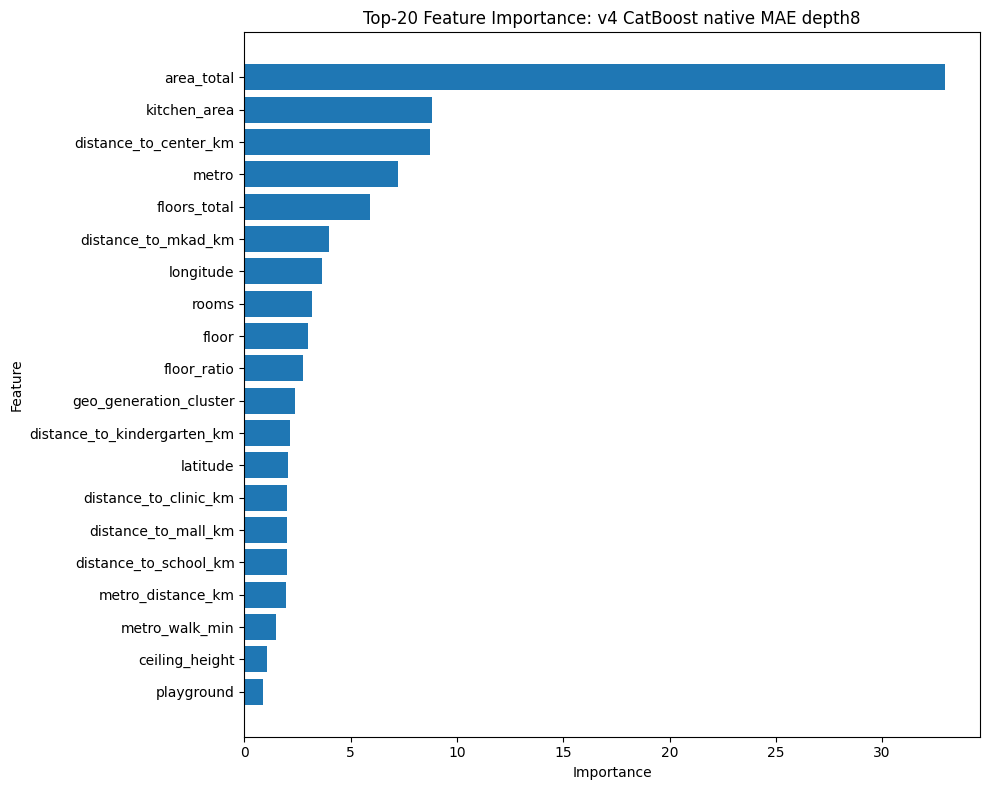

Feature importance saved to: artifacts/feature_importance_v4_catboost_mae_depth8.csv


In [20]:
feature_importance = model_v4_mae_depth8.get_feature_importance(
    Pool(X_train_cb, y_train_raw, cat_features=cat_feature_indices)
)

fi_df = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": feature_importance,
}).sort_values("importance", ascending=False)

top20_fi = fi_df.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20_fi["feature"], top20_fi["importance"])
plt.title("Top-20 Feature Importance: v4 CatBoost native MAE depth8")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

fi_path = ARTIFACT_DIR / "feature_importance_v4_catboost_mae_depth8.csv"
fi_df.to_csv(fi_path, index=False, encoding="utf-8-sig")
print("Feature importance saved to:", fi_path)

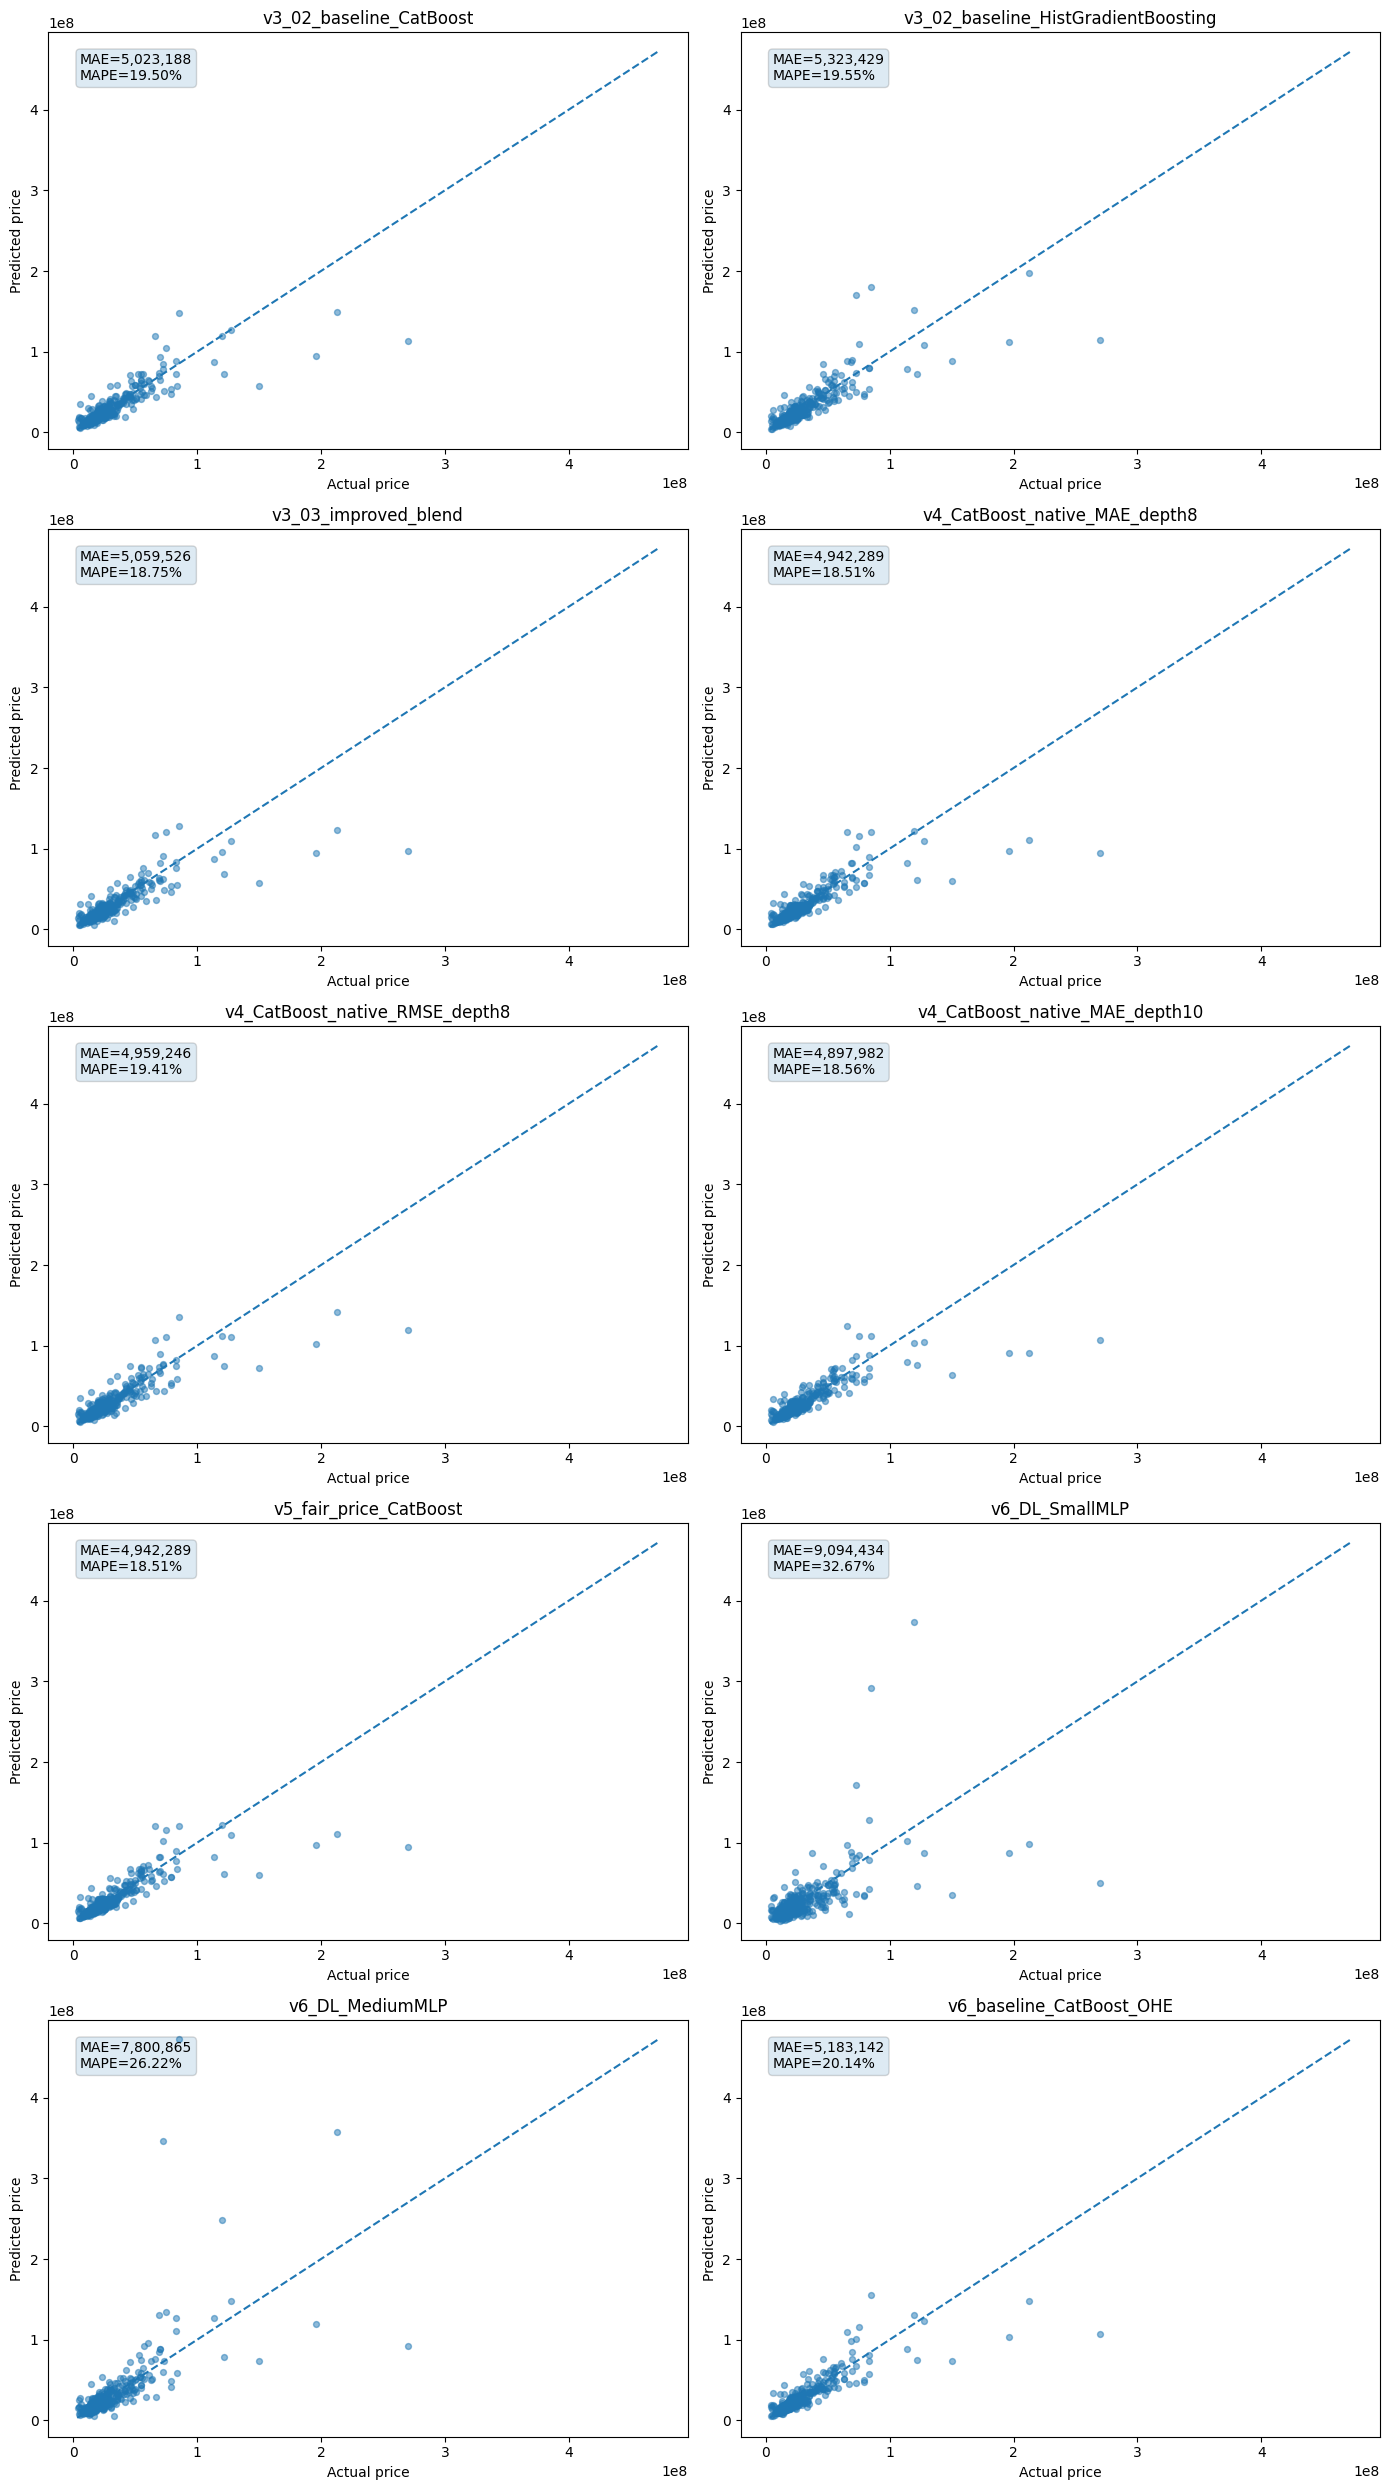

Predictions saved to: artifacts/test_predictions_all_models.csv


,actual_price,v3_02_baseline_CatBoost,v3_02_baseline_HistGradientBoosting,v3_03_improved_blend,v4_CatBoost_native_MAE_depth8,v4_CatBoost_native_RMSE_depth8,v4_CatBoost_native_MAE_depth10,v5_fair_price_CatBoost,v6_DL_SmallMLP,v6_DL_MediumMLP,v6_baseline_CatBoost_OHE
0,79000000.0,4.708721e+07,4.571283e+07,4.574338e+07,5.700544e+07,5.147846e+07,5.498215e+07,5.700544e+07,33988140.0,41258904.0,5.066447e+07
1,28000000.0,3.581496e+07,3.098367e+07,3.090987e+07,2.745651e+07,3.548879e+07,2.888746e+07,2.745651e+07,30280922.0,31970950.0,3.197728e+07
2,19499000.0,1.515626e+07,1.662608e+07,1.604317e+07,1.683300e+07,1.516051e+07,1.621683e+07,1.683300e+07,11289349.0,18191012.0,1.739430e+07
3,114000000.0,8.699185e+07,7.866772e+07,8.674636e+07,8.198468e+07,8.678483e+07,8.040822e+07,8.198468e+07,101598048.0,126926728.0,8.850228e+07
4,47900000.0,2.920309e+07,2.726051e+07,2.776791e+07,2.715244e+07,2.876210e+07,3.122665e+07,2.715244e+07,17144114.0,24323700.0,3.161656e+07


In [21]:
model_names = list(predictions.keys())
n_models = len(model_names)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).reshape(-1)

y_min = min(y_test.min(), min(np.min(predictions[name]) for name in model_names))
y_max = max(y_test.max(), max(np.max(predictions[name]) for name in model_names))

for ax, name in zip(axes, model_names):
    y_pred = predictions[name]
    ax.scatter(y_test, y_pred, alpha=0.5, s=18)
    ax.plot([y_min, y_max], [y_min, y_max], linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")

    model_metrics = regression_metrics(y_test, y_pred)
    ax.text(
        0.05,
        0.95,
        f"MAE={model_metrics['MAE']:,.0f}\nMAPE={model_metrics['MAPE'] * 100:.2f}%",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

predictions_df = pd.DataFrame({"actual_price": y_test.values})
for name, pred in predictions.items():
    predictions_df[name] = pred

predictions_path = ARTIFACT_DIR / "test_predictions_all_models.csv"
predictions_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")
print("Predictions saved to:", predictions_path)
display(predictions_df.head())

## 19. Сохранение лучшей модели и артефактов

In [22]:
production_model_name = "v4_CatBoost_native_MAE_depth8"
production_model = model_v4_mae_depth8

production_dir = ARTIFACT_DIR / "avm_catboost_v4_native_mae_depth8"
production_dir.mkdir(parents=True, exist_ok=True)

model_path = production_dir / "model.cbm"
production_model.save_model(str(model_path))

with open(production_dir / "feature_list.json", "w", encoding="utf-8") as f:
    json.dump(list(X_train_cb.columns), f, ensure_ascii=False, indent=2)

with open(production_dir / "categorical_features.json", "w", encoding="utf-8") as f:
    json.dump(cat_cols, f, ensure_ascii=False, indent=2)

with open(production_dir / "categorical_feature_indices.json", "w", encoding="utf-8") as f:
    json.dump(cat_feature_indices, f, ensure_ascii=False, indent=2)

production_metrics = regression_metrics(y_test, pred_v4_mae_depth8)

metrics_json = {
    "model_name": production_model_name,
    "random_seed": RANDOM_SEED,
    "target_col": TARGET_COL,
    "repo_url": REPO_URL,
    "train_real_rows": int((train_df["is_synthetic"] == 0).sum()),
    "train_synthetic_rows": int((train_df["is_synthetic"] == 1).sum()),
    "train_total_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "sample_weight_real": 1.0,
    "sample_weight_synthetic": 0.5,
    "metrics_test": {
        "MAE": float(production_metrics["MAE"]),
        "MAPE": float(production_metrics["MAPE"]),
        "RMSE": float(production_metrics["RMSE"]),
        "R2": float(production_metrics["R2"]),
    },
    "removed_leakage_cols": LEAKAGE_COLS,
    "removed_useless_cols": USELESS_COLS,
    "model_params": {
        "algorithm": "CatBoostRegressor",
        "loss_function": "MAE",
        "depth": 8,
        "cat_features": "native",
    }
}

with open(production_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_json, f, ensure_ascii=False, indent=2)

preprocessing_metadata = {
    "common_features": list(X_train_cb.columns),
    "numeric_features": num_cols,
    "categorical_features": cat_cols,
    "cat_feature_indices": cat_feature_indices,
    "dropped_columns": {
        "leakage": LEAKAGE_COLS,
        "useless": USELESS_COLS,
        "technical": TECHNICAL_COLS,
        "all_empty": all_empty_cols,
        "constant": constant_cols,
    },
    "categorical_stabilization": {
        "enabled": True,
        "unknown_fill_value": "unknown",
        "renovation_map": RENOVATION_MAP,
        "parking_map": PARKING_MAP,
        "walls_map": WALLS_MAP,
        "metro_rules": [
            "lowercase",
            "strip",
            "remove m. prefix",
            "keep text before comma",
            "collapse multiple spaces"
        ]
    }
}

with open(production_dir / "preprocessing_metadata.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_metadata, f, ensure_ascii=False, indent=2)

joblib.dump(extra_artifacts, ARTIFACT_DIR / "extra_experiment_artifacts.joblib")

model_card = f"""# Model Card: AVM CatBoost v4 Native MAE depth8

## Назначение

Модель оценивает стоимость объектов недвижимости в Москве.

## Данные

Данные загружаются из GitHub-репозитория:

{REPO_URL}

- Real train: {int((train_df["is_synthetic"] == 0).sum())}
- Synthetic train: {int((train_df["is_synthetic"] == 1).sum())}
- Total train: {int(len(train_df))}
- Original test: {int(len(test_df))}

## Препроцессинг

- унифицирование колонок real train / synthetic train / test;
- удаление leakage-признаков: price, price_per_m2, link;
- удаление бесполезных признаков, включая house_number при наличии;
- стабилизация категориальных признаков;
- sample weights: real = 1.0, synthetic = 0.5.

## Модель

CatBoostRegressor:

- loss_function = MAE
- depth = 8
- random_seed = 42
- categorical features = native CatBoost handling

## Test metrics

| Metric | Value |
|---|---:|
| MAE | {production_metrics["MAE"]:,.0f} |
| MAPE | {production_metrics["MAPE"] * 100:.2f}% |
| RMSE | {production_metrics["RMSE"]:,.0f} |
| R2 | {production_metrics["R2"]:.4f} |
"""

(production_dir / "model_card.md").write_text(model_card, encoding="utf-8")

print("Production artifacts saved to:", production_dir)
print("Model:", model_path)

Production artifacts saved to: artifacts/avm_catboost_v4_native_mae_depth8
Model: artifacts/avm_catboost_v4_native_mae_depth8/model.cbm
